## **Customer Churn Prediction using Logistic Regression**

The Telco Customer Churn dataset (sourced from Kaggle) is used to analyze customer behavior and build a machine learning model to predict whether a customer is likely to churn (1) or not churn (0). The project involves data preprocessing, exploratory data analysis, feature engineering, and model building using Logistic Regression.

This analysis helps telecommunication companies identify high-risk customers and make data-driven decisions for targeted retention campaigns, optimizing customer engagement and reducing churn.

In [ ]:

!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
import pandas as pd

file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(file_path)



### 1) Exploratory Data Analysis

The Python library Pandas was used to perform exploratory data analysis (EDA) and gain insights into the dataset. This included understanding data distributions, identifying missing values, and detecting potential correlations between features.

Visualization libraries such as Matplotlib and Seaborn were used to analyze relationships between variables and uncover patterns influencing customer churn. These insights guided effective data preprocessing and feature engineering for model development.

In [ ]:

df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


There are no rows with null or missing values in the given dataset. Most customers are in the non - senior citizen category, indicating that the SeniorCitizen column is dominated by non-senior customers. 7043 records of customers exist in total.

In [ ]:
df['Churn'].value_counts(normalize = True)

,proportion
Churn,
No,0.73463
Yes,0.26537


Class imbalance is observed in the target variable (Churn), where approximately 73% of the observations belong to the 'No' class. This imbalance can cause the model to become biased toward the majority class, leading to poor performance in predicting churn (minority class).

To address this issue, class imbalance was handled by applying balanced class weights in the Logistic Regression model, ensuring that misclassification of the minority class is penalized more heavily during training.

In [ ]:
df.groupby('Churn')['MonthlyCharges'].mean()



,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.groupby('Churn')['TotalCharges'].mean()

,TotalCharges
Churn,
No,2555.344141
Yes,1531.796094


On an average, customers who do not churn tend to have higher total charges, indicating longer tenure and sustained engagement with the service. In contrast, customers who churn generally exhibit higher monthly average charges, suggesting that higher recurring costs may contribute to churn behavior.

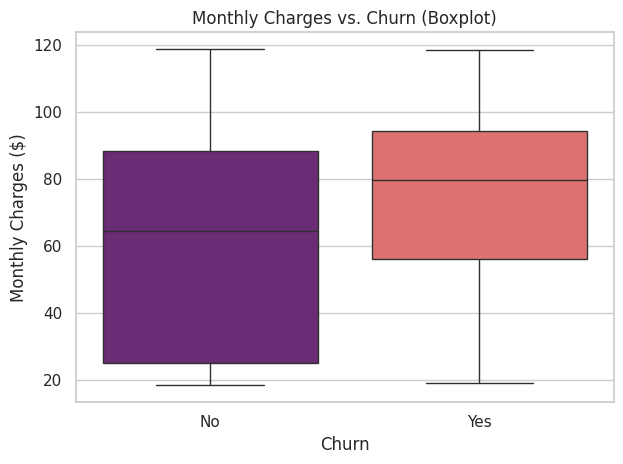

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

ax = sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='magma', legend=False)

ax.set_title('Monthly Charges vs. Churn (Boxplot)')
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

On an average, customers that churned paid more month-to-month charges than customers who did
not.

In [ ]:
pd.crosstab(df['Contract'], df['Churn'])


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Month-to-month customers have the highest retention as well as the highest churn frequency. Customers availing a two year contract have the least churn frequency.

<Axes: xlabel='Churn', ylabel='tenure'>

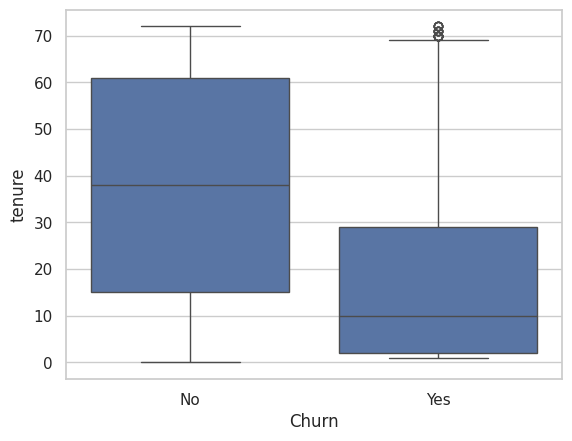

In [ ]:
sns.boxplot(data=df, x='Churn', y='tenure')

Churned customers generally have lower tenure than their non-churned counterparts

In [ ]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
df['StreamingTV'] = df['StreamingTV'].replace({
    'No': 0,
    'Yes': 1,
    'No internet service': 0
})

df['StreamingMovies'] = df['StreamingMovies'].replace({
    'No': 0,
    'Yes': 1,
    'No internet service': 0
})

/tmp/ipykernel_7947/421615416.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['StreamingTV'] = df['StreamingTV'].replace({
/tmp/ipykernel_7947/421615416.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['StreamingMovies'] = df['StreamingMovies'].replace({


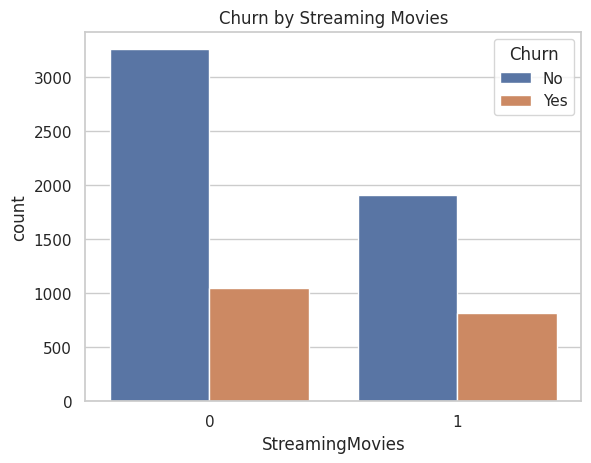

In [ ]:
sns.countplot(data=df, x='StreamingMovies', hue='Churn')
plt.title('Churn by Streaming Movies')
plt.show()

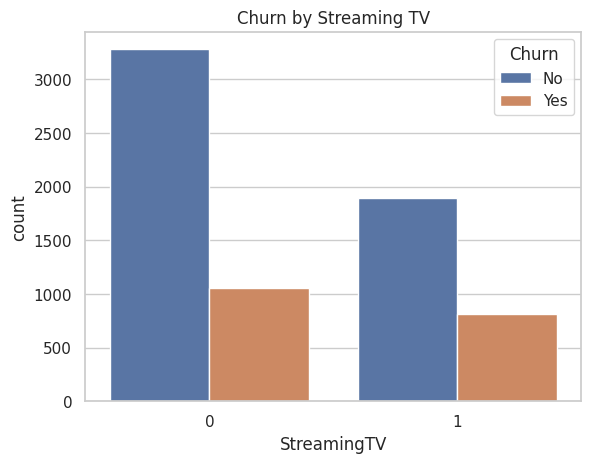

In [ ]:
sns.countplot(data=df, x='StreamingTV', hue='Churn')
plt.title('Churn by Streaming TV')
plt.show()

<Axes: xlabel='InternetService', ylabel='MonthlyCharges'>

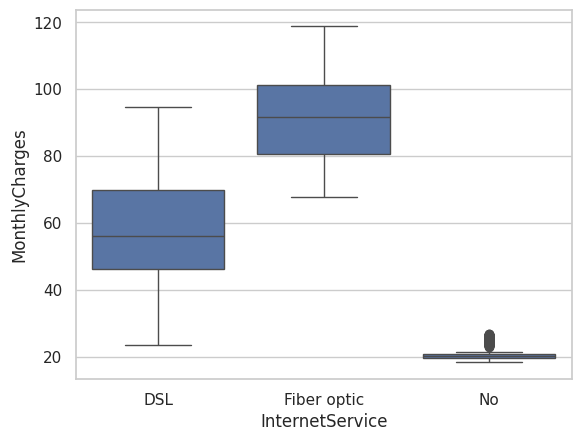

In [ ]:
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges')

Customers that have availed Fiber Optic Internet Service have the highest monthly charges as well as the highest average charge.

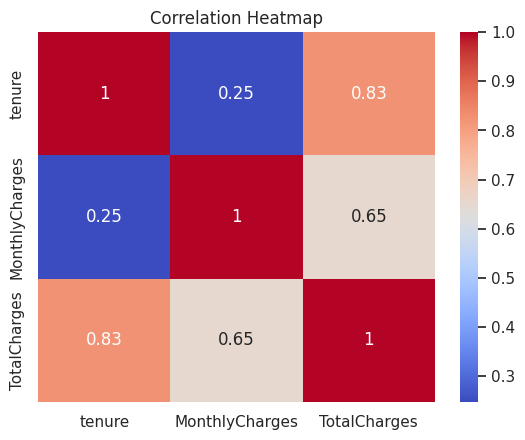

In [ ]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


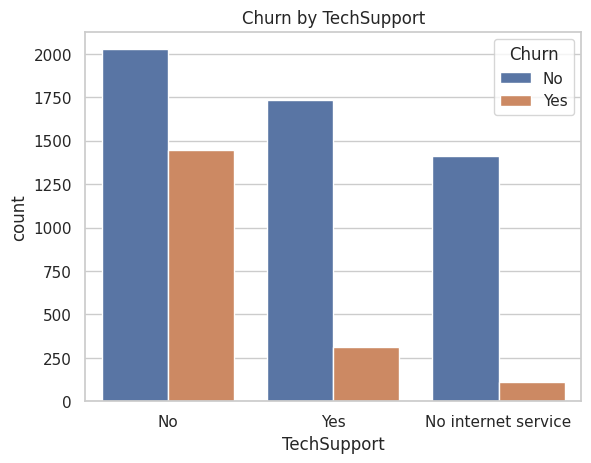

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Churn by TechSupport')
plt.show()

Customers with no tech support have the highest churn and retention frequency. Customers with no internet service are the least likely to churn.

### 2) Data Preprocessing

Following exploratory data analysis, data preprocessing was performed to prepare the dataset for model training. This included removing duplicate entries and handling missing values (NaN/None) to ensure data quality and consistency.

Categorical variables were transformed using one-hot encoding for features with multiple categories. Additionally, binary categorical variables (e.g., Yes/No) were converted into numerical format (0/1) to make them suitable for machine learning algorithms.

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

In [ ]:
cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'MultipleLines'
]
# Columns with redundant third categories which mean the same as 'No' are replaced
for col in cols:
    df[col] = df[col].str.strip().str.title()  # clean text
    df[col] = df[col].apply(lambda x: x if x in ['Yes', 'No'] else 'No')

In [ ]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,0,0,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,1,1,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,1,0,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No,DSL,Yes,...,No,No,0,0,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,1,1,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,0,0,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
multi_cat_cols = ['Contract','PaymentMethod', 'InternetService']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [ ]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
  df[col] = df[col].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_7947/2035883401.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})


Columns having redundant categories such as 'No Internet service' (which is the same as 'No') have been replaced with only two categories ('Yes', 'No') for simplicity. Multi-category variables are encoded avoiding multicollinearity by dropping the first category (important for logistic regression). All string values are converted to binary 0/1 to make the data interpretable by machine learning models.

In [ ]:
y_n_cols = df.select_dtypes(include = 'object').columns

for col in y_n_cols:
  df[col] = df[col].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_7947/3315491216.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,Female,0,1,0,1,0,0,0,1,...,29.85,29.85,0,False,False,False,True,False,False,False
1,5575-GNVDE,Male,0,0,0,34,1,0,1,0,...,56.95,1889.50,0,True,False,False,False,True,False,False
2,3668-QPYBK,Male,0,0,0,2,1,0,1,1,...,53.85,108.15,1,False,False,False,False,True,False,False
3,7795-CFOCW,Male,0,0,0,45,0,0,1,0,...,42.30,1840.75,0,True,False,False,False,False,False,False
4,9237-HQITU,Female,0,0,0,2,1,0,0,0,...,70.70,151.65,1,False,False,False,True,False,True,False


In [ ]:
df.drop('customerID', axis=1, inplace=True)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [ ]:
df = df.astype({col: 'int64' for col in df.select_dtypes('bool').columns})

In [ ]:
print(df.dtypes)

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
Contract_One year                          int64
Contract_Two year                          int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Electr

In [ ]:
print(df.isnull().sum().sum())

0


No missing values found and all the columns have been converted to int64/float64 to make it suitable for ML Models

### 3) Model Training
Library used is sckit-learn.

The dataset was first split into training and testing sets to evaluate model performance on unseen data. Numerical features were then standardized to ensure consistent feature scaling, as differences in magnitude can negatively impact model convergence and performance in gradient-based algorithms.

A Logistic Regression model was trained on the processed data. To improve the model’s ability to identify churn cases, the classification threshold was adjusted from the default 0.5 to 0.45, prioritizing recall while maintaining a reasonable balance with precision.


In [ ]:
x = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight = 'balanced', max_iter=5000)
lr.fit(X_train, y_train)

y_prob = lr.predict_proba(X_test)[:, 1]
threshold = 0.45
y_pred_lr = (y_prob >= threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))


Logistic Regression:
               precision    recall  f1-score   support

           0       0.92      0.67      0.77      1033
           1       0.48      0.83      0.61       374

    accuracy                           0.71      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.71      0.73      1407



### 4) Model Evaluation

The Logistic Regression model demonstrates a balanced performance in predicting customer churn, with an overall accuracy of 71%. However, given the class imbalance in the dataset and the business objective, accuracy alone is not a reliable metric.

For the non-churn class (0), the model achieves a high precision score of 0.92, indicating that most customers predicted as non-churners are correctly classified. However, the recall for this class is 0.67, suggesting that some non-churning customers are incorrectly classified as churners.

For the churn class (1), which is the primary focus of this analysis, the model achieves a recall of 0.83, meaning that 83% of actual churners are correctly identified. This is a strong result, as identifying potential churners is critical for retention strategies. The precision for this class is 0.48, indicating that while the model captures most churners, it also produces some false positives.

The F1-score (combining the three metrics: accuracy, precision and recall) for the churn class is 0.61, reflecting a reasonable balance between precision and recall. This performance is achieved through the use of class balancing and probability threshold tuning, which prioritizes recall to ensure that most churn cases are captured.

Overall, the model is effective for churn prediction, as it successfully identifies a large proportion of at-risk customers. While precision can be further improved, the current model is well-suited for business scenarios where missing a churner (false negative) is more costly for the company than incorrectly flagging a non-churner (false positive).